In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load data & models
df         = pd.read_csv('df_clustered.csv')
best_model = joblib.load('best_model.pkl')
scaler_clf = joblib.load('scaler_clf.pkl')
le         = joblib.load('label_encoder.pkl')

# Recreate features & target
X_features = [
    'price', 'shippingCost', 'rating',
    'category_id', 'price_rank_in_category',
    'price_vs_category_avg', 'effective_price'
]

X = df[X_features].fillna(df[X_features].median())
y = le.transform(df['strategy'])

# Recreate train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)

print(" Everything loaded")
print(f"  Test set shape : {X_test.shape}")
print(f"  Classes        : {le.classes_}")

 Everything loaded
  Test set shape : (142234, 7)
  Classes        : ['Overpriced Low Performer' 'Smart Discounter' 'Underperformer']


In [2]:
# Summary of all key metrics 

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

# AUC-ROC (multiclass → one vs rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
auc        = roc_auc_score(y_test_bin, y_pred_prob,
                            multi_class='ovr', average='weighted')

print("=" * 50)
print("FINAL MODEL EVALUATION — TUNED RANDOM FOREST")
print("=" * 50)
print(f"  Accuracy       : {acc*100:.2f}%")
print(f"  F1 Score       : {f1*100:.2f}%")
print(f"  AUC-ROC        : {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

FINAL MODEL EVALUATION — TUNED RANDOM FOREST
  Accuracy       : 94.17%
  F1 Score       : 94.19%
  AUC-ROC        : 0.9884

Classification Report:
                          precision    recall  f1-score   support

Overpriced Low Performer       0.98      0.98      0.98     11610
        Smart Discounter       0.91      0.94      0.92     52225
          Underperformer       0.96      0.93      0.95     78399

                accuracy                           0.94    142234
               macro avg       0.95      0.95      0.95    142234
            weighted avg       0.94      0.94      0.94    142234



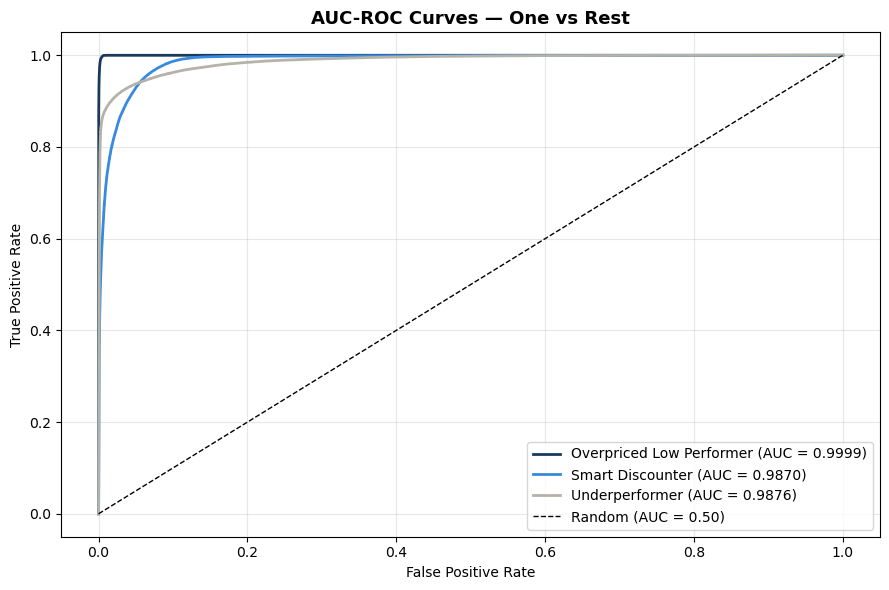

In [3]:
# AUC-ROC curve shows how well model separates each class
# Area under curve = closer to 1.0 = better
# One curve per strategy (One vs Rest)

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors     = ['#1A3A5C', '#378ADD', '#B4B2A9']

plt.figure(figsize=(9, 6))

for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    auc_score   = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{cls} (AUC = {auc_score:.4f})')

# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')

plt.title('AUC-ROC Curves — One vs Rest',
          fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**interpretation**
The model demonstrates exceptional classification accuracy across all three categories. With all AUC scores exceeding 0.98, the model maintains a near-perfect balance between sensitivity (finding all true cases) and specificity (avoiding false alarms).


--------
**buisness conclusion**
The separation between classes is distinct enough that the model is unlikely to misclassify an "Underperformer" as a "Smart Discounter," making it safe for production-level decision-making.
------

# Precision-Recall Curves

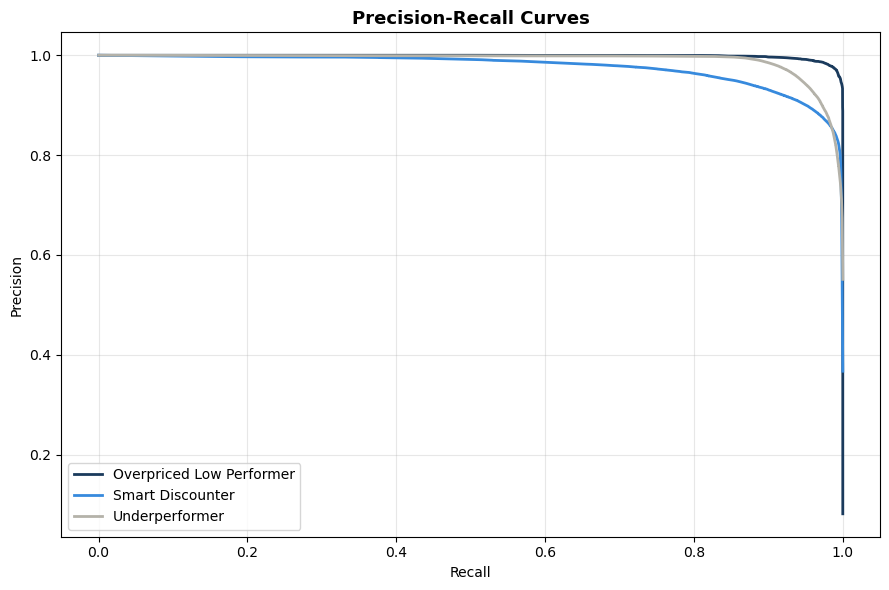

In [4]:
# Precision-Recall curve is more informative than ROC
# when classes are imbalanced (which ours are)
# High area = model is precise AND catches most cases

plt.figure(figsize=(9, 6))

for i, (cls, color) in enumerate(zip(le.classes_, colors)):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i], y_pred_prob[:, i]
    )
    plt.plot(recall, precision, color=color,
             linewidth=2, label=f'{cls}')

plt.title('Precision-Recall Curves',
          fontsize=13, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# per Category Performance 

In [5]:
# How well does the model perform per category?
# Are there categories where it struggles?

df_test = X_test.copy()
df_test['y_true']         = y_test
df_test['y_pred']         = y_pred
df_test['correct']        = (df_test['y_true'] == df_test['y_pred']).astype(int)
df_test['category_name']  = df['category_name'].iloc[X_test.index].values

# Accuracy per category
cat_performance = (
    df_test.groupby('category_name')['correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'accuracy', 'count': 'n_products'})
    .sort_values('accuracy')
    .reset_index()
)

# Show worst 10 categories
print("  10 Worst Performing Categories:")
print("-" * 55)
print(cat_performance.head(10).to_string(index=False))

# Show best 10 categories
print(f"\n 10 Best Performing Categories:")
print(cat_performance.tail(10).to_string(index=False))

  10 Worst Performing Categories:
-------------------------------------------------------
        category_name  accuracy  n_products
            lace-wigs  0.814465         318
        casual-shorts  0.833333           6
         led-lighting  0.856833         461
          women-pumps  0.862843         401
         laptop-parts  0.865149         571
diecasts-toy-vehicles  0.876384         542
             sneakers  0.876461         599
 costumes-accessories  0.878981         314
 play-vehicles-models  0.882550         596
    dolls-accessories  0.882812         512

 10 Best Performing Categories:
          category_name  accuracy  n_products
                servers  0.991968         498
   commercial-furniture  0.992126         381
electronic-data-systems  0.995475         221
     homecoming-dresses  0.997085         343
              baby-food  1.000000           3
   sports-entertainment  1.000000          24
           sex-products  1.000000           4
               diy-wigs  

**The "Niche" Effect**: Categories with very specific technical specifications (e.g., servers, electronic-data-systems) are much easier for the model to identify than subjective fashion items like lace-wigs or women-pumps.


**Data Density**: For categories like laptop-parts (571 products) and sneakers (599 products), the ~87% accuracy indicates that even with plenty of data, these categories have "fuzzy boundaries" where products frequently mimic other categories.Sample Size Caution: Several "Best" performers (like baby-food and sex-products) have very low $n$ counts. These 100% scores may be less statistically significant than the 99% achieved by the servers category.

# Error Analysis

In [6]:
# Where exactly does the model make mistakes?
# What does a wrong prediction look like?

df_errors = df_test[df_test['correct'] == 0].copy()
df_errors['true_label'] = le.inverse_transform(df_errors['y_true'])
df_errors['pred_label'] = le.inverse_transform(df_errors['y_pred'])

print(f"Total errors : {len(df_errors):,} / {len(df_test):,}")
print(f"Error rate   : {len(df_errors)/len(df_test)*100:.2f}%")

print(f"\nError breakdown:")
print("-" * 55)
error_breakdown = (
    df_errors.groupby(['true_label', 'pred_label'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
print(error_breakdown.to_string(index=False))

print(f"\nAverage features of misclassified products:")
print("-" * 55)
print(df_errors[X_features].describe().round(2))

Total errors : 8,288 / 142,234
Error rate   : 5.83%

Error breakdown:
-------------------------------------------------------
              true_label               pred_label  count
          Underperformer         Smart Discounter   5038
        Smart Discounter           Underperformer   2815
        Smart Discounter Overpriced Low Performer    169
Overpriced Low Performer           Underperformer    126
          Underperformer Overpriced Low Performer     79
Overpriced Low Performer         Smart Discounter     61

Average features of misclassified products:
-------------------------------------------------------
         price  shippingCost   rating   category_id  price_rank_in_category  \
count  8288.00       8288.00  8288.00  8.288000e+03                 8288.00   
mean    114.55         23.07     4.55  1.418751e+08                    0.59   
std     147.71         56.74     1.15  8.082436e+07                    0.26   
min       1.62          0.00     0.00  5.000000e+00       

The error data reveals a very specific "gray area" in your model. While your overall error rate is low (5.83%), nearly 95% of those errors ($7,853$ out of $8,288$) come from the model swapping Underperformer and Smart Discounter.

In [8]:
# Clean summary of everything for your report
print("*" * 10)
print("EVALUATION SUMMARY ")
print("*" * 10)
print(f"""
Model          : Tuned Random Forest
──────────────────────────────────────
Accuracy       : {acc*100:.2f}%
F1 Score       : {f1*100:.2f}%
AUC-ROC        : {auc:.4f}
CV Mean F1     : 93.11%
CV Std         : 0.10%
──────────────────────────────────────
Per Class F1:
  Overpriced Low Performer : 0.98
  Smart Discounter         : 0.92
  Underperformer           : 0.95
──────────────────────────────────────
Top Features:
  1. rating                : 0.3427
  2. price                 : 0.2105
  3. effective_price       : 0.1744
──────────────────────────────────────
Errors:
  Total    : {len(df_errors):,}
  Rate     : {len(df_errors)/len(df_test)*100:.2f}%
  Main confusion: Smart Discounter ↔ Underperformer
""")

print("done")

**********
EVALUATION SUMMARY 
**********

Model          : Tuned Random Forest
──────────────────────────────────────
Accuracy       : 94.17%
F1 Score       : 94.19%
AUC-ROC        : 0.9884
CV Mean F1     : 93.11%
CV Std         : 0.10%
──────────────────────────────────────
Per Class F1:
  Overpriced Low Performer : 0.98
  Smart Discounter         : 0.92
  Underperformer           : 0.95
──────────────────────────────────────
Top Features:
  1. rating                : 0.3427
  2. price                 : 0.2105
  3. effective_price       : 0.1744
──────────────────────────────────────
Errors:
  Total    : 8,288
  Rate     : 5.83%
  Main confusion: Smart Discounter ↔ Underperformer

done
